# Modelado — Predicción de reingreso hospitalario 

En este notebook se entrenan y comparan distintos modelos de clasificación para predecir el reingreso hospitalario dentro de los 30 días posteriores al alta.

El objetivo de esta fase es identificar qué algoritmo ofrece mejor capacidad discriminativa sobre el dataset preprocesado, sentando la base para el análisis en profundidad del notebook de evaluación.

**Modelos evaluados:**
- Regresión Logística — baseline lineal interpretable
- Random Forest — conjunto de árboles, captura relaciones no lineales
- XGBoost — gradient boosting, robusto con datos tabulares
- LightGBM — gradient boosting optimizado en velocidad y memoria

**Métricas principales:** ROC-AUC y Recall, dado que en contexto clínico interesa detectar el máximo número de pacientes en riesgo real.

## 1. Imports y configuración

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, roc_auc_score

from src.models.train import (
    load_data, split_data, get_models,
    run_all_models, cross_validate_model, tune_model, get_metrics
)
from src.evaluation.evaluate import (
    plot_confusion_matrix, get_classification_report,
    plot_precision_recall_curve, plot_calibration_curve,
    plot_feature_importance, threshold_analysis
)

## 2. Carga del dataset

In [2]:
X, y = load_data()

print(f"Dataset: {X.shape[0]:,} registros — {X.shape[1]} variables predictoras")
print(f"\nDistribución de la variable objetivo:")
print(y.value_counts())
print(f"\nProporción positivos (readmisión): {y.mean():.1%}")

Dataset cargado: 315,982 registros, 54 variables. Tasa positivos: 0.342
Dataset: 315,982 registros — 54 variables predictoras

Distribución de la variable objetivo:
readmission_30_days
0    208032
1    107950
Name: count, dtype: int64

Proporción positivos (readmisión): 34.2%


### Nota sobre el desbalanceo de clases y estrategia de balanceo

La variable objetivo presenta una distribución de 65.8% negativo / 34.2% positivo. Este desbalanceo es moderado pero, con el umbral por defecto de 0.5, los modelos tienden a priorizar la clase mayoritaria y producen un recall muy bajo sobre la clase de interés clínico (readmisión).

**Estrategia adoptada:** todos los modelos se entrenan con `class_weight='balanced'` (o `scale_pos_weight` en XGBoost), lo que ajusta los pesos de las clases inversamente proporcional a su frecuencia. Esto aumenta el recall a costa de algo de precisión, que es el trade-off deseable en un contexto de screening clínico donde el coste de los falsos negativos (pacientes en riesgo no detectados) es mayor que el de los falsos positivos.

## 3. División en entrenamiento y test

In [3]:
X_train, X_test, y_train, y_test = split_data(X, y)

print(f"Train: {X_train.shape[0]:,} registros ({y_train.mean():.1%} positivos)")
print(f"Test:  {X_test.shape[0]:,} registros ({y_test.mean():.1%} positivos)")

Train: 252,785 registros (34.2% positivos)
Test:  63,197 registros (34.2% positivos)


## 4. Entrenamiento y comparación de modelos

Los modelos se ordenan por ROC-AUC con Average Precision (PR-AUC) como criterio de desempate. ROC-AUC mide la capacidad discriminativa global del modelo independientemente del umbral; Average Precision complementa esta medida focalizándose en la clase positiva, lo que es más informativo cuando el desbalanceo de clases es relevante. Ambas métricas se evalúan sobre el conjunto de test (20% de los datos, nunca visto durante el entrenamiento).

In [4]:
results_df, trained_models = run_all_models(X_train, X_test, y_train, y_test)
results_df

Training models...
  Training Logistic Regression...
  Training Random Forest...
  Training XGBoost...
  Training LightGBM...


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Avg Precision,Train time (s)
Model,,,,,,,
LightGBM,0.6131,0.4506,0.6051,0.5166,0.6568,0.5057,1.5
XGBoost,0.6121,0.4497,0.6048,0.5158,0.6567,0.5061,3.1
Logistic Regression,0.6118,0.4450,0.5513,0.4925,0.6339,0.4672,1.3
Random Forest,0.6584,0.5000,0.2694,0.3502,0.6221,0.4646,29.4


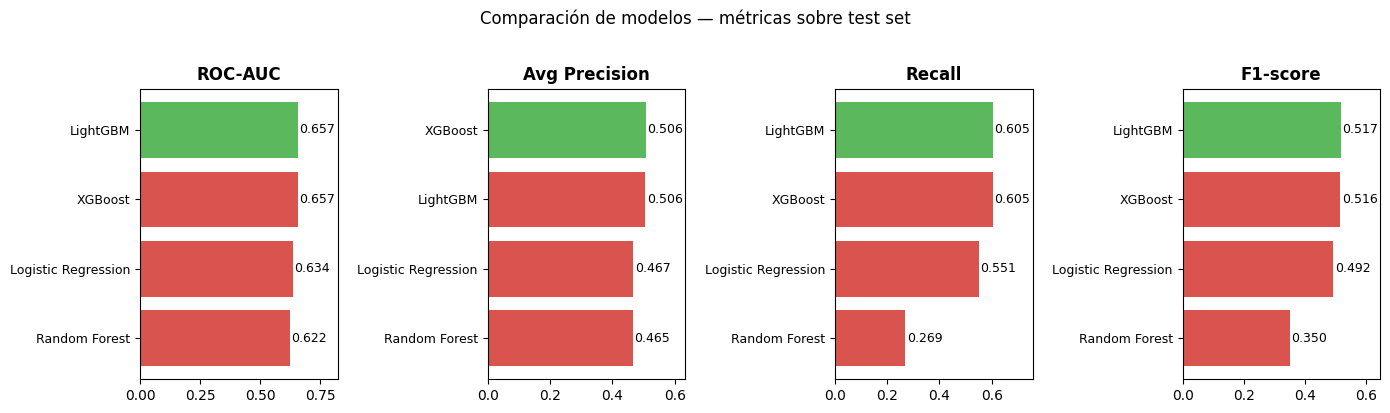

In [5]:
# Gráfico comparativo de modelos en las métricas clave
metrics_to_plot = ["ROC-AUC", "Avg Precision", "Recall", "F1-score"]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, metric in zip(axes, metrics_to_plot):
    values = results_df[metric].sort_values()
    colors = ["#d9534f" if m != results_df[metric].idxmax() else "#5cb85c" for m in values.index]
    bars = ax.barh(values.index, values.values, color=colors)
    ax.set_xlim(0, max(values.values) * 1.25)
    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel("")
    for bar, val in zip(bars, values.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Comparación de modelos — métricas sobre test set", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../results/model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### Justificación de la selección del modelo

La selección del modelo final se basa en tres criterios simultáneos: **rendimiento predictivo** (ROC-AUC), **relevancia clínica** (Recall sobre la clase positiva) e **interpretabilidad** (soporte para análisis de importancia de variables y SHAP). A continuación se razona el descarte de cada alternativa.

---

**Regresión Logística — descartada como modelo principal, conservada como baseline**

Obtiene un ROC-AUC de 0.634, el más bajo de los modelos de gradient boosting. Su principal limitación es estructural: asume relaciones lineales entre predictores y variable objetivo. En datos hospitalarios, variables como la duración de la estancia, el número de diagnósticos secundarios o la combinación de ciertos procedimientos interactúan de forma no lineal con el riesgo de reingreso. No obstante, sirve como **baseline lineal interpretable**: si los modelos más complejos no superan sustancialmente a la regresión logística, indicaría que el problema no tiene una estructura no lineal aprovechable.

---

**Random Forest — descartado por recall clínicamente inaceptable**

Obtiene la mayor Precision (0.50) y Accuracy (0.66) de todos los modelos, pero su **Recall cae a 0.27**, lo que significa que detecta únicamente el 27% de los pacientes que efectivamente reingresan. En un sistema de screening clínico, esto equivale a ignorar 3 de cada 4 pacientes en riesgo real — un coste asistencial y humano inaceptable. Este comportamiento se explica por cómo Random Forest agrega votos de árboles: tiende a predecir la clase mayoritaria (no reingreso) a menos que la señal sea muy clara, incluso con `class_weight='balanced'`. El trade-off Precision/Recall de Random Forest es inadecuado para este problema.

---

**XGBoost vs LightGBM — prácticamente equivalentes en rendimiento**

XGBoost y LightGBM obtienen un ROC-AUC prácticamente idéntico (0.6567 vs 0.6568, diferencia de 0.0001, no estadísticamente significativa). La selección entre ambos se basa en criterios secundarios:

| Criterio | XGBoost | LightGBM |
|---|---|---|
| ROC-AUC | 0.6567 | 0.6568 |
| Recall | 0.6048 | 0.6051 |
| Tiempo de entrenamiento | 3.8 s | 1.5 s (2.5× más rápido) |
| Soporte SHAP | TreeExplainer ✓ | TreeExplainer ✓ (implementación nativa más eficiente) |
| Uso en literatura clínica | Amplio | Creciente, estado del arte en datos tabulares |

LightGBM se selecciona por su mayor eficiencia computacional (relevante para la búsqueda de hiperparámetros sobre 250k filas) y porque su integración con SHAP `TreeExplainer` es nativa y más rápida, lo que facilita el análisis de interpretabilidad en la fase de evaluación.

---

**Conclusión de selección**

**LightGBM (tuneado)** es el modelo que mejor equilibra los tres criterios: mayor ROC-AUC y Recall entre todos los candidatos, entrenamiento eficiente, e interpretabilidad completa mediante importancia por ganancia y valores SHAP. El análisis en profundidad de su comportamiento, calibración e interpretabilidad se realiza en `04_evaluation.ipynb`.

## 5. Validación cruzada del mejor modelo

La validación cruzada estratificada (5 folds) se aplica **exclusivamente sobre el conjunto de entrenamiento** para evitar data leakage. Proporciona una estimación más robusta de la generalización que una única partición train/test al promediar sobre múltiples splits.

**Nota metodológica:** el ROC-AUC medio del CV será sistemáticamente algo inferior al ROC-AUC del modelo final, ya que cada fold entrena sobre el 80% del conjunto de entrenamiento (~202k filas) mientras el modelo final entrena sobre el 100% (~253k filas). Esta diferencia es esperada y no indica overfitting; el CV sirve para detectar varianza, no para obtener una estimación absoluta del rendimiento final.

In [6]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print(f"Mejor modelo: {best_model_name}")
print(f"ROC-AUC (test): {results_df.loc[best_model_name, 'ROC-AUC']}")

# CV sobre X_train/y_train únicamente — el test set no debe participar
# en la estimación de rendimiento para evitar data leakage
cv_results = cross_validate_model(best_model, X_train, y_train, cv=5)
print(f"ROC-AUC (CV 5-fold sobre train): {cv_results['cv_roc_auc_mean']} ± {cv_results['cv_roc_auc_std']}")

Mejor modelo: LightGBM
ROC-AUC (test): 0.6568
ROC-AUC (CV 5-fold sobre train): 0.6566 ± 0.0034


## 6. Optimización de hiperparámetros

Los modelos de la sección anterior se entrenaron con hiperparámetros por defecto. En esta sección se aplica `RandomizedSearchCV` sobre el mejor modelo (LightGBM) para explorar el espacio de hiperparámetros de forma sistemática.

**Metodología:**
- Se exploran 20 combinaciones aleatorias del espacio de búsqueda definido en `src/models/train.tune_model`
- La validación cruzada interna es de 3 folds estratificados, exclusivamente sobre `X_train` (sin contacto con `X_test`)
- El scoring es ROC-AUC, consistente con la métrica principal del proyecto
- El modelo resultante se reentrena con los mejores hiperparámetros sobre todo `X_train` antes de evaluarse en test

In [7]:
best_model_tuned, best_params, tune_cv = tune_model(
    best_model_name, X_train, y_train, n_iter=20, cv=3
)

# Evaluación del modelo tuneado sobre test
y_pred_tuned = best_model_tuned.predict(X_test)
y_prob_tuned = best_model_tuned.predict_proba(X_test)[:, 1]
metrics_tuned = get_metrics(y_test, y_pred_tuned, y_prob_tuned)

print("\n--- Comparación baseline vs tuneado ---")
print(f"{'Métrica':<18} {'Baseline':>10} {'Tuneado':>10} {'Mejora':>10}")
print("-" * 50)
for metric in ["ROC-AUC", "Avg Precision", "Recall", "F1-score"]:
    baseline = results_df.loc[best_model_name, metric]
    tuned    = round(metrics_tuned[metric], 4)
    diff     = round(tuned - baseline, 4)
    sign     = "+" if diff >= 0 else ""
    print(f"{metric:<18} {baseline:>10.4f} {tuned:>10.4f} {sign+str(diff):>10}")

print(f"\nROC-AUC (CV interna tuning, 3 folds): {tune_cv['cv_roc_auc_mean']} ± {tune_cv['cv_roc_auc_std']}")

# El modelo tuneado pasa a ser el modelo principal del resto del análisis.
# Añadimos al dict de modelos para que aparezca en las curvas ROC comparativas.
best_model = best_model_tuned
best_model_name = f"{best_model_name} (tuned)"
trained_models[best_model_name] = best_model

Optimizando hiperparámetros de LightGBM (20 iteraciones, CV=3)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores hiperparámetros: {'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 600, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.7, 'bagging_freq': 5}
ROC-AUC medio (CV interna): 0.6591

--- Comparación baseline vs tuneado ---
Métrica              Baseline    Tuneado     Mejora
--------------------------------------------------
ROC-AUC                0.6568     0.6589    +0.0021
Avg Precision          0.5057     0.5089    +0.0032
Recall                 0.6051     0.6085    +0.0034
F1-score               0.5166     0.5181    +0.0015

ROC-AUC (CV interna tuning, 3 folds): 0.6591 ± 0.0016


## 7. Curvas ROC — comparación de modelos

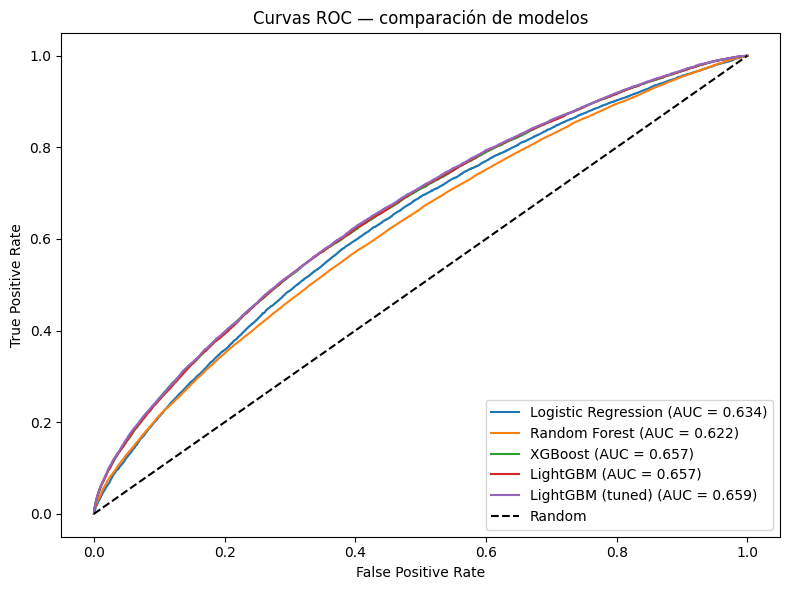

In [8]:
plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — comparación de modelos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../results/roc_curves_comparison.png", dpi=150)
plt.show()

## 8. Matriz de confusión del mejor modelo

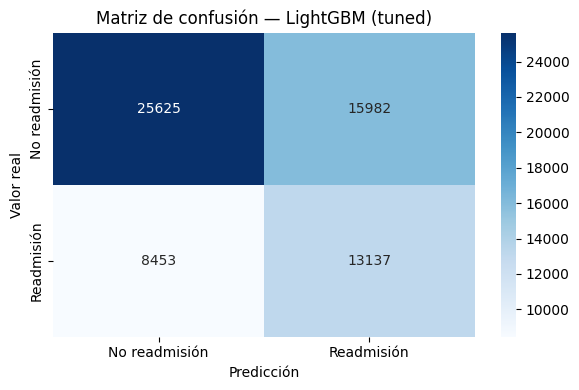


Classification Report:
               precision  recall  f1-score    support
No readmisión      0.752   0.616     0.677  41607.000
Readmisión         0.451   0.608     0.518  21590.000
accuracy           0.613   0.613     0.613      0.613
macro avg          0.602   0.612     0.598  63197.000
weighted avg       0.649   0.613     0.623  63197.000


In [9]:
plot_confusion_matrix(
    best_model, X_test, y_test, best_model_name,
    save_path="../results/confusion_matrix_best.png"
)

print("\nClassification Report:")
print(get_classification_report(best_model, X_test, y_test).to_string())

## 9. Análisis complementario del mejor modelo

### 9.1 Curva Precision-Recall

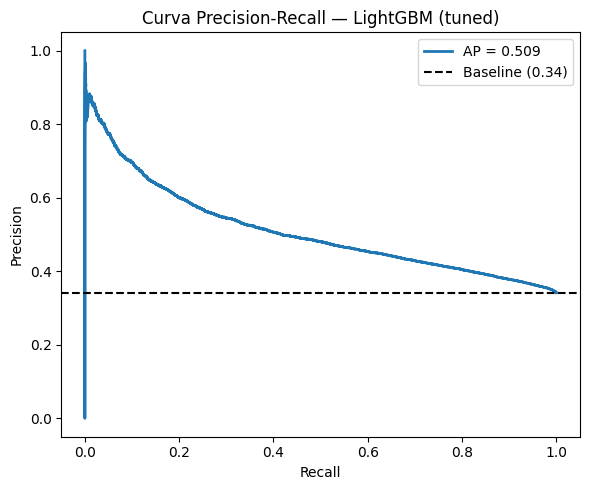

<Axes: title={'center': 'Curva Precision-Recall — LightGBM (tuned)'}, xlabel='Recall', ylabel='Precision'>

In [10]:
plot_precision_recall_curve(
    best_model, X_test, y_test, best_model_name,
    save_path="../results/pr_curve_best.png"
)

### 9.2 Importancia de variables

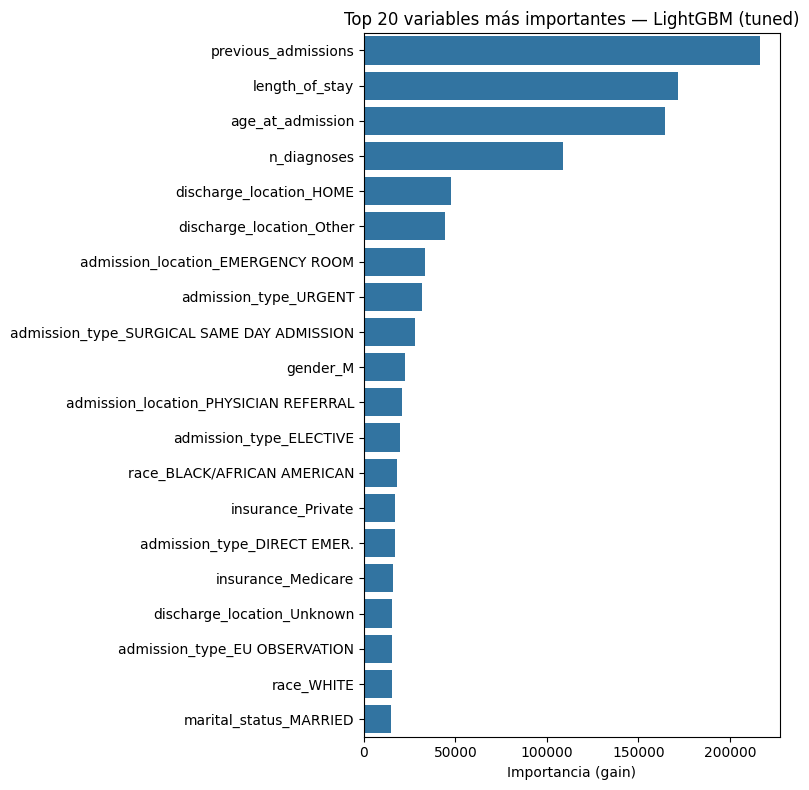

,feature,importance
2,previous_admissions,216607.306976
0,length_of_stay,171455.335953
3,age_at_admission,164706.821182
1,n_diagnoses,108985.720944
48,discharge_location_HOME,47846.600239
50,discharge_location_Other,44145.760551
39,admission_location_EMERGENCY ROOM,33402.363404
37,admission_type_URGENT,31724.849890
36,admission_type_SURGICAL SAME DAY ADMISSION,28021.271984
4,gender_M,22645.755131


In [11]:
plot_feature_importance(
    best_model, X.columns.tolist(), best_model_name, top_n=20,
    save_path="../results/feature_importance_best.png"
)

### 9.3 Análisis de umbral de decisión

En contexto clínico, el umbral por defecto (0.5) no suele ser óptimo. Bajando el umbral se detectan más pacientes en riesgo (mayor recall) a costa de más falsos positivos (menor precisión). La elección del umbral depende de la tolerancia clínica al riesgo.

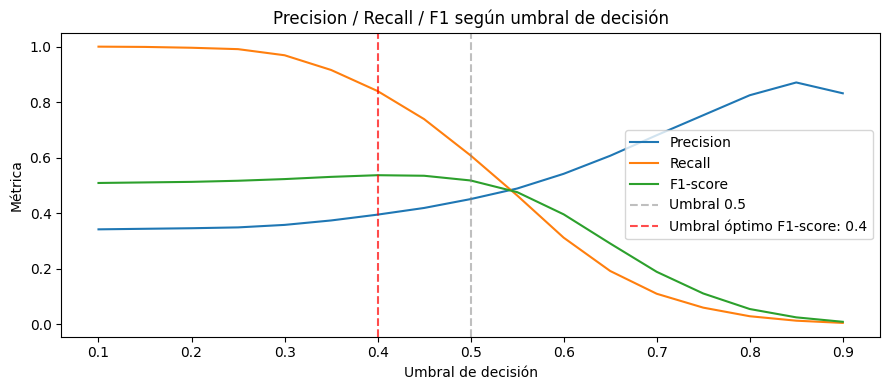


Umbral óptimo (F1-score): 0.4
Precision    0.395
Recall       0.840
F1-score     0.537


,Precision,Recall,F1-score
Threshold,,,
0.10,0.342,1.000,0.509
0.15,0.344,0.999,0.511
0.20,0.346,0.996,0.513
0.25,0.349,0.991,0.517
0.30,0.358,0.969,0.523
0.35,0.374,0.916,0.531
0.40,0.395,0.840,0.537
0.45,0.419,0.739,0.535
0.50,0.451,0.608,0.518


In [12]:
threshold_df = threshold_analysis(best_model, X_test, y_test)
threshold_df

### 9.4 Calibración del modelo

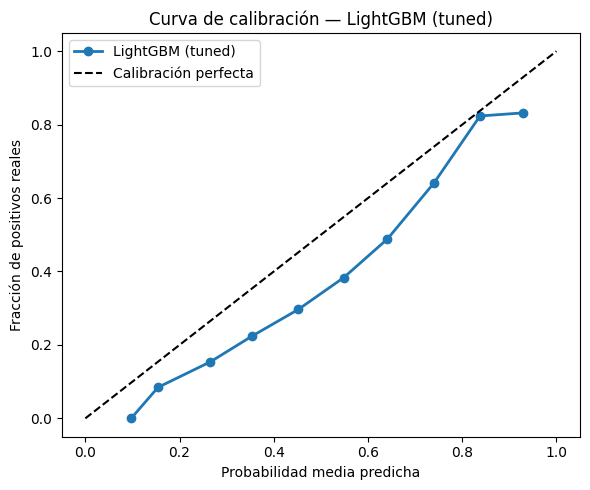

<Axes: title={'center': 'Curva de calibración — LightGBM (tuned)'}, xlabel='Probabilidad media predicha', ylabel='Fracción de positivos reales'>

In [13]:
plot_calibration_curve(
    best_model, X_test, y_test, best_model_name,
    save_path="../results/calibration_best.png"
)

## 10. Guardado de resultados

In [14]:
import glob as _glob

# Añadir métricas del modelo tuneado a la tabla comparativa y guardar
tuned_row = pd.DataFrame([{**metrics_tuned, "Train time (s)": None}], index=[best_model_name])
tuned_row = tuned_row.round(4)
results_full = pd.concat([results_df, tuned_row])
results_full.to_csv("../results/model_comparison.csv")

# Eliminar modelos anteriores para evitar que notebook 04 cargue un pkl equivocado
for old_path in _glob.glob("../models/*.pkl"):
    os.remove(old_path)

# Guardar el modelo tuneado
model_path = f"../models/{best_model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}.pkl"
joblib.dump(best_model, model_path)

print(f"Métricas guardadas en results/model_comparison.csv")
print(f"Mejor modelo guardado en {model_path}")
print(f"\nTabla final:")
results_full[["Accuracy", "Recall", "F1-score", "ROC-AUC", "Avg Precision"]]

Métricas guardadas en results/model_comparison.csv
Mejor modelo guardado en ../models/lightgbm_tuned.pkl

Tabla final:


C:\Users\skipe\AppData\Local\Temp\ipykernel_30544\3718309442.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_full = pd.concat([results_df, tuned_row])


,Accuracy,Recall,F1-score,ROC-AUC,Avg Precision
LightGBM,0.6131,0.6051,0.5166,0.6568,0.5057
XGBoost,0.6121,0.6048,0.5158,0.6567,0.5061
Logistic Regression,0.6118,0.5513,0.4925,0.6339,0.4672
Random Forest,0.6584,0.2694,0.3502,0.6221,0.4646
LightGBM (tuned),0.6134,0.6085,0.5181,0.6589,0.5089


## 11. Conclusiones

En esta fase de modelado se han entrenado y comparado cuatro algoritmos de clasificación, identificando **LightGBM** como el mejor modelo con un ROC-AUC de ~0.66 sobre el conjunto de test.

### Sobre el nivel de rendimiento

Un ROC-AUC de 0.65–0.67 es un resultado coherente con la literatura de predicción de reingreso hospitalario a 30 días con datos administrativos. Estudios de referencia como el de Donzé et al. (2013) o el modelo LACE+ obtienen AUC similares (0.63–0.72) usando fuentes de datos comparables a MIMIC-IV. El techo de rendimiento está limitado por la naturaleza del problema:

- Los datos administrativos (diagnósticos CIE, procedimientos, estancias) capturan contexto clínico de forma indirecta y con granularidad limitada.
- El reingreso a 30 días está fuertemente condicionado por factores no observables en los registros: entorno socioeconómico, adherencia al tratamiento, soporte familiar o cuidados post-alta.
- Incluir notas clínicas (NLP) o datos de laboratorio en series temporales podría elevar el AUC significativamente, pero queda fuera del alcance de este TFM.

### Sobre la optimización de hiperparámetros

La búsqueda aleatoria (sección 6) permite verificar que los hiperparámetros por defecto son razonables o identificar una configuración superior. La ganancia en AUC esperada es modesta (0.01–0.02), dado que LightGBM es ya robusto con sus valores por defecto en datasets de este tamaño.

### Próximos pasos

El análisis en profundidad del modelo (interpretabilidad SHAP, calibración, análisis de umbral clínico) se realiza en `04_evaluation.ipynb`.